In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [15]:
# Configuration
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
num_classes = len(class_names)
INPUT_SIZE = 224
EMBED_DIM = 144
NUM_HEADS = 12
FF_DIM = 288
NUM_TRANSFORMER_BLOCKS = 2
DROPOUT = 0.2
GAMMA_VALUE = 1.5

print('Configuration loaded')

Configuration loaded


In [16]:
# Model architecture
class PatchEmbedding(nn.Module):
    def __init__(self, in_channels, embed_dim, patch_size=16):
        super(PatchEmbedding, self).__init__()
        self.patch_embed = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.norm = nn.LayerNorm(embed_dim)
    
    def forward(self, x):
        x = self.patch_embed(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)
        return x

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super(MultiHeadSelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert self.head_dim * num_heads == embed_dim
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
        
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return x

class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super(TransformerEncoderBlock, self).__init__()
        self.attention = MultiHeadSelfAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.dropout1 = nn.Dropout(dropout)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, embed_dim),
            nn.Dropout(dropout)
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        
    def forward(self, x):
        attn_output = self.attention(x)
        x = x + self.dropout1(attn_output)
        x = self.norm1(x)
        ffn_output = self.ffn(x)
        x = x + ffn_output
        x = self.norm2(x)
        return x

class MobileNetViT(nn.Module):
    def __init__(self, num_classes, embed_dim=144, num_heads=12, ff_dim=288, num_transformer_blocks=2, dropout=0.1):
        super(MobileNetViT, self).__init__()
        mobilenet_full = models.mobilenet_v2(weights=None)
        self.mobilenet = mobilenet_full.features
        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))
        mobilenet_out_channels = 1280
        self.patch_embedding = PatchEmbedding(in_channels=mobilenet_out_channels, embed_dim=embed_dim, patch_size=1)
        num_patches = 49
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, embed_dim))
        self.transformer_blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_transformer_blocks)
        ])
        self.local_conv = nn.Sequential(
            nn.Conv2d(mobilenet_out_channels, embed_dim, kernel_size=1),
            nn.BatchNorm2d(embed_dim),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fusion = nn.Linear(embed_dim * 2, embed_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        mobilenet_features = self.mobilenet(x)
        mobilenet_features = self.adaptive_pool(mobilenet_features)
        tokens = self.patch_embedding(mobilenet_features)
        tokens = tokens + self.pos_embedding
        num_tokens = tokens.shape[1]
        split_point = num_tokens // 2
        q1_tokens = tokens[:, :split_point, :]
        q2_tokens = tokens[:, split_point:, :]
        for transformer_block in self.transformer_blocks:
            q2_tokens = transformer_block(q2_tokens)
        global_features = q2_tokens.mean(dim=1)
        local_features = self.local_conv(mobilenet_features)
        local_features = local_features.flatten(1)
        fused_features = torch.cat([local_features, global_features], dim=1)
        fused_features = self.fusion(fused_features)
        fused_features = self.dropout(fused_features)
        output = self.classifier(fused_features)
        return output

print('Model architecture defined')

Model architecture defined


In [17]:
# Load model
print('Loading MobileNetViT model...')

mobilenetvit_model = MobileNetViT(
    num_classes=num_classes,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_transformer_blocks=NUM_TRANSFORMER_BLOCKS,
    dropout=DROPOUT
)

mobilenetvit_checkpoint = torch.load(
    '/kaggle/input/datasets/rahmymuhammadh/brain-tumor-models/mobilenetvit_brain_tumor_model.pth', 
    map_location=device,
    weights_only=False
)

mobilenetvit_model.load_state_dict(mobilenetvit_checkpoint['model_state_dict'], strict=False)
mobilenetvit_model = mobilenetvit_model.to(device)
mobilenetvit_model.eval()

print('Model loaded successfully')

Loading MobileNetViT model...
Model loaded successfully


In [18]:
# Optimized Score-CAM implementation
# Key optimizations for speed:
# 1. Process only top-K most important channels (reduces computation)
# 2. Larger batch size for parallel processing (improves GPU utilization)
# 3. Single forward pass for channel importance scoring

class OptimizedScoreCAM:
    def __init__(self, model, target_layer, top_k=64):
        """
        Initialize Optimized Score-CAM
        model: Neural network model
        target_layer: Layer to extract activations from
        top_k: Number of top channels to process (default 64, reduces from ~1280)
        """
        self.model = model
        self.target_layer = target_layer
        self.top_k = top_k
        self.activations = None
        
        # Register hook to capture activations
        self.handle = self.target_layer.register_forward_hook(self.save_activation)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def generate_cam(self, input_image, target_class=None, batch_size=128):
        """
        Generate optimized Score-CAM activation map
        
        Optimizations:
        1. Select top-K channels by importance before processing
        2. Use larger batch size (128 instead of 32) for speed
        3. Process fewer channels with minimal accuracy loss
        
        batch_size: Number of activation maps to process at once
        """
        self.model.eval()
        
        # Get original prediction
        with torch.no_grad():
            base_output = self.model(input_image)
            if target_class is None:
                target_class = base_output.argmax(dim=1).item()
        
        # Get activations from target layer
        with torch.no_grad():
            _ = self.model(input_image)
        
        activations = self.activations[0]
        num_channels = activations.shape[0]
        
        # Optimization: Select only top-K most important channels
        # This dramatically reduces computation time
        if num_channels > self.top_k:
            # Quick importance scoring using activation magnitude
            # Channels with higher magnitude typically contribute more
            channel_importance = activations.abs().mean(dim=(1, 2))
            top_indices = torch.topk(channel_importance, k=self.top_k).indices
            activations = activations[top_indices]
            num_channels = self.top_k
            print(f'Processing top {self.top_k} channels out of {self.activations[0].shape[0]} for speed')
        
        # Upsample all activations to input size at once
        activations_upsampled = F.interpolate(
            activations.unsqueeze(0),
            size=input_image.shape[2:],
            mode='bilinear',
            align_corners=False
        )[0]
        
        # Normalize each activation map
        activations_normalized = []
        for i in range(num_channels):
            act = activations_upsampled[i]
            act_min = act.min()
            act_max = act.max()
            if act_max > act_min:
                act_norm = (act - act_min) / (act_max - act_min)
            else:
                act_norm = torch.zeros_like(act)
            activations_normalized.append(act_norm)
        
        activations_normalized = torch.stack(activations_normalized)
        
        # Calculate importance weights for each activation map
        weights = []
        
        print(f'Computing importance scores (batch size: {batch_size})...')
        
        # Process in batches for efficiency
        for start_idx in range(0, num_channels, batch_size):
            end_idx = min(start_idx + batch_size, num_channels)
            batch_acts = activations_normalized[start_idx:end_idx]
            
            # Create masked inputs for this batch
            batch_masked_inputs = []
            for act in batch_acts:
                act_expanded = act.unsqueeze(0).expand(3, -1, -1)
                masked_input = input_image[0] * act_expanded
                batch_masked_inputs.append(masked_input)
            
            batch_masked_inputs = torch.stack(batch_masked_inputs)
            
            # Get predictions for all masked inputs in batch
            with torch.no_grad():
                batch_outputs = self.model(batch_masked_inputs)
                batch_scores = batch_outputs[:, target_class]
            
            weights.extend(batch_scores.cpu().numpy().tolist())
        
        # Convert weights to tensor and apply ReLU
        weights = torch.tensor(weights, device=activations.device)
        weights = F.relu(weights)
        
        # Normalize weights
        if weights.sum() > 0:
            weights = weights / weights.sum()
        
        # Create weighted combination of activation maps
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=activations.device)
        for i in range(num_channels):
            cam += weights[i] * activations[i]
        
        # Apply ReLU and normalize
        cam = F.relu(cam)
        if cam.max() > 0:
            cam = cam / cam.max()
        
        return cam.cpu().numpy(), target_class
    
    def remove_hook(self):
        self.handle.remove()

print('Optimized Score-CAM class defined')
print('Speed optimizations:')
print('  - Processes top-64 channels only (instead of all 1280)')
print('  - Batch size 128 for faster parallel processing')
print('  - Expected time: 1-2 seconds per image')

Optimized Score-CAM class defined
Speed optimizations:
  - Processes top-64 channels only (instead of all 1280)
  - Batch size 128 for faster parallel processing
  - Expected time: 1-2 seconds per image


In [19]:
# Initialize Score-CAM
target_layer = mobilenetvit_model.mobilenet[-3]
scorecam = OptimizedScoreCAM(mobilenetvit_model, target_layer, top_k=64)

print('Score-CAM initialized')

Score-CAM initialized


In [20]:
# Simplified Score-CAM Evaluator
class ScoreCAMEvaluator:
    def __init__(self, model, scorecam, test_images, test_labels, class_names, device):
        self.model = model
        self.scorecam = scorecam
        self.test_images = test_images
        self.test_labels = test_labels
        self.class_names = class_names
        self.device = device
    
    def preprocess_for_model(self, image):
        """Convert numpy image to preprocessed tensor"""
        if image.dtype == np.uint8:
            image = image.astype(np.float32) / 255.0
        
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float()
        
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image_tensor = (image_tensor - mean) / std
        
        return image_tensor.unsqueeze(0)
    
    def evaluate_efficiency(self, num_samples=100):
        """
        Measure efficiency metrics for Score-CAM
        Matches existing model evaluation format
        Returns: Time, FLOPs estimation, Overhead
        """
        print(f'Evaluating Score-CAM efficiency on {num_samples} samples from test set...')
        print()
        
        model_times = []
        scorecam_times = []
        total_times = []
        times_per_class = {class_name: {'model': [], 'scorecam': [], 'total': []} 
                          for class_name in self.class_names}
        
        # Random sample from test set
        indices = np.random.choice(len(self.test_images), 
                                  min(num_samples, len(self.test_images)), 
                                  replace=False)
        
        for idx in tqdm(indices, desc='Measuring inference times'):
            image = self.test_images[idx]
            label = self.test_labels[idx]
            
            # Convert label to integer index if it's a string
            if isinstance(label, (np.str_, str)):
                label_idx = self.class_names.index(label)
            else:
                label_idx = int(label)
            
            label_name = self.class_names[label_idx]
            
            # Preprocess
            image_tensor = self.preprocess_for_model(image)
            image_tensor = image_tensor.to(self.device)
            
            # Measure MODEL inference time
            start_model = time.time()
            with torch.no_grad():
                output = self.model(image_tensor)
                pred_class = output.argmax(dim=1).item()
            model_time = (time.time() - start_model) * 1000  # Convert to milliseconds
            
            # Measure SCORE-CAM time
            start_scorecam = time.time()
            cam, _ = self.scorecam.generate_cam(image_tensor, target_class=pred_class, batch_size=128)
            scorecam_time = (time.time() - start_scorecam) * 1000  # Convert to milliseconds
            
            # Total time
            total_time = model_time + scorecam_time
            
            # Store results
            model_times.append(model_time)
            scorecam_times.append(scorecam_time)
            total_times.append(total_time)
            
            times_per_class[label_name]['model'].append(model_time)
            times_per_class[label_name]['scorecam'].append(scorecam_time)
            times_per_class[label_name]['total'].append(total_time)
        
        # Calculate statistics
        results = {
            'model_inference': {
                'mean_ms': np.mean(model_times),
                'std_ms': np.std(model_times),
                'min_ms': np.min(model_times),
                'max_ms': np.max(model_times),
                'fps': 1000 / np.mean(model_times)
            },
            'scorecam': {
                'mean_ms': np.mean(scorecam_times),
                'std_ms': np.std(scorecam_times),
                'min_ms': np.min(scorecam_times),
                'max_ms': np.max(scorecam_times),
                'fps': 1000 / np.mean(scorecam_times)
            },
            'total_system': {
                'mean_ms': np.mean(total_times),
                'std_ms': np.std(total_times),
                'min_ms': np.min(total_times),
                'max_ms': np.max(total_times),
                'fps': 1000 / np.mean(total_times)
            },
            'overhead_factor': np.mean(scorecam_times) / np.mean(model_times),
            'times_per_class': {}
        }
        
        # Per-class statistics
        for class_name in self.class_names:
            if len(times_per_class[class_name]['model']) > 0:
                results['times_per_class'][class_name] = {
                    'model_mean_ms': np.mean(times_per_class[class_name]['model']),
                    'scorecam_mean_ms': np.mean(times_per_class[class_name]['scorecam']),
                    'total_mean_ms': np.mean(times_per_class[class_name]['total']),
                    'count': len(times_per_class[class_name]['model'])
                }
        
        return results
    
    def run_evaluation(self, num_samples=100):
        """Run efficiency evaluation only"""
        print('Running Score-CAM Efficiency Evaluation')
        print('Measuring: Time, FPS, Overhead')
        print()
        
        results = self.evaluate_efficiency(num_samples=num_samples)
        
        return results
    
    def print_results(self, results):
        """Print results in thesis-ready format"""
        print()
        print('SCORE-CAM EFFICIENCY EVALUATION RESULTS')
        print()
        
        print('COMPONENT BREAKDOWN:')
        print()
        print('1. Model Inference (Classification):')
        print(f'   Time: {results["model_inference"]["mean_ms"]:.2f} ± {results["model_inference"]["std_ms"]:.2f} ms')
        print(f'   FPS: {results["model_inference"]["fps"]:.2f}')
        print(f'   Min: {results["model_inference"]["min_ms"]:.2f} ms')
        print(f'   Max: {results["model_inference"]["max_ms"]:.2f} ms')
        print()
        
        print('2. Score-CAM (Explainability):')
        print(f'   Time: {results["scorecam"]["mean_ms"]:.2f} ± {results["scorecam"]["std_ms"]:.2f} ms')
        print(f'   FPS: {results["scorecam"]["fps"]:.2f}')
        print(f'   Min: {results["scorecam"]["min_ms"]:.2f} ms')
        print(f'   Max: {results["scorecam"]["max_ms"]:.2f} ms')
        print()
        
        print('3. Total System (Classification + Explainability):')
        print(f'   Time: {results["total_system"]["mean_ms"]:.2f} ± {results["total_system"]["std_ms"]:.2f} ms')
        print(f'   FPS: {results["total_system"]["fps"]:.2f}')
        print(f'   Min: {results["total_system"]["min_ms"]:.2f} ms')
        print(f'   Max: {results["total_system"]["max_ms"]:.2f} ms')
        print()
        
        print(f'OVERHEAD ANALYSIS:')
        print(f'   Score-CAM overhead: {results["overhead_factor"]:.1f}x model inference time')
        print()
        
        print('TIME PER CLASS:')
        for class_name, stats in results['times_per_class'].items():
            print(f'   {class_name}:')
            print(f'      Model: {stats["model_mean_ms"]:.2f} ms')
            print(f'      Score-CAM: {stats["scorecam_mean_ms"]:.2f} ms')
            print(f'      Total: {stats["total_mean_ms"]:.2f} ms')
            print(f'      Samples: {stats["count"]}')
        print()
        
        print('FLOPs Estimation (for reference):')
        print('   Model FLOPs: 0.62 G (from your training metrics)')
        print('   Score-CAM FLOPs: ~40 G (64 forward passes × 0.62)')
        print('   Total FLOPs: ~40.62 G')
    
    def save_results(self, results, filename='scorecam_efficiency_results.txt'):
        """Save results to file"""
        with open(filename, 'w') as f:
            f.write('SCORE-CAM EFFICIENCY EVALUATION\n')
            f.write('=' * 60 + '\n\n')
            
            f.write('COMPONENT PERFORMANCE:\n\n')
            
            f.write('Model Inference:\n')
            f.write(f'  Time: {results["model_inference"]["mean_ms"]:.2f} ms\n')
            f.write(f'  FPS: {results["model_inference"]["fps"]:.2f}\n\n')
            
            f.write('Score-CAM:\n')
            f.write(f'  Time: {results["scorecam"]["mean_ms"]:.2f} ms\n')
            f.write(f'  FPS: {results["scorecam"]["fps"]:.2f}\n\n')
            
            f.write('Total System:\n')
            f.write(f'  Time: {results["total_system"]["mean_ms"]:.2f} ms\n')
            f.write(f'  FPS: {results["total_system"]["fps"]:.2f}\n\n')
            
            f.write(f'Overhead Factor: {results["overhead_factor"]:.1f}x\n\n')
            
            f.write('Per-Class Timing:\n')
            for class_name, stats in results['times_per_class'].items():
                f.write(f'\n{class_name}:\n')
                f.write(f'  Model: {stats["model_mean_ms"]:.2f} ms\n')
                f.write(f'  Score-CAM: {stats["scorecam_mean_ms"]:.2f} ms\n')
                f.write(f'  Total: {stats["total_mean_ms"]:.2f} ms\n')
        
        print(f'Results saved to {filename}')

print('Simplified ScoreCAM Evaluator defined (efficiency metrics only)')

Simplified ScoreCAM Evaluator defined (efficiency metrics only)


In [21]:
# Load test set
print('Loading test set...')
test_images = np.load('/kaggle/input/datasets/rahmymuhammadh/brain-tumor-mri-preprocess-sets/preprocessed_test_images.npy')
test_labels = np.load('/kaggle/input/datasets/rahmymuhammadh/brain-tumor-mri-preprocess-sets/preprocessed_test_labels.npy')

print(f'Test set loaded: {len(test_images)} images')
print(f'Image shape: {test_images[0].shape}')
print(f'Labels shape: {test_labels.shape}')

Loading test set...
Test set loaded: 1311 images
Image shape: (256, 256, 3)
Labels shape: (1311,)


In [22]:
# Create evaluator instance
evaluator = ScoreCAMEvaluator(
    model=mobilenetvit_model,
    scorecam=scorecam,
    test_images=test_images,
    test_labels=test_labels,
    class_names=class_names,
    device=device
)

print('Evaluator created and ready')

Evaluator created and ready


In [23]:
# Run complete evaluation

results = evaluator.run_evaluation(num_samples=100)

Running Score-CAM Efficiency Evaluation
Measuring: Time, FPS, Overhead

Evaluating Score-CAM efficiency on 100 samples from test set...



Measuring inference times:   0%|          | 0/100 [00:00<?, ?it/s]

Processing top 64 channels out of 160 for speed
Computing importance scores (batch size: 128)...


Measuring inference times:   2%|▏         | 2/100 [00:00<00:08, 12.16it/s]

Processing top 64 channels out of 160 for speed
Computing importance scores (batch size: 128)...
Processing top 64 channels out of 160 for speed
Computing importance scores (batch size: 128)...
Processing top 64 channels out of 160 for speed
Computing importance scores (batch size: 128)...


...

Measuring inference times:  96%|█████████▌| 96/100 [00:07<00:00, 13.12it/s]

Processing top 64 channels out of 160 for speed
Computing importance scores (batch size: 128)...
Processing top 64 channels out of 160 for speed
Computing importance scores (batch size: 128)...


Measuring inference times:  98%|█████████▊| 98/100 [00:07<00:00, 13.14it/s]

Processing top 64 channels out of 160 for speed
Computing importance scores (batch size: 128)...
Processing top 64 channels out of 160 for speed
Computing importance scores (batch size: 128)...


Measuring inference times: 100%|██████████| 100/100 [00:07<00:00, 13.02it/s]


In [24]:
# Print formatted results
evaluator.print_results(results)


SCORE-CAM EFFICIENCY EVALUATION RESULTS

COMPONENT BREAKDOWN:

1. Model Inference (Classification):
   Time: 6.78 ± 0.57 ms
   FPS: 147.48
   Min: 5.91 ms
   Max: 10.68 ms

2. Score-CAM (Explainability):
   Time: 68.44 ± 0.96 ms
   FPS: 14.61
   Min: 66.85 ms
   Max: 73.28 ms

3. Total System (Classification + Explainability):
   Time: 75.23 ± 1.41 ms
   FPS: 13.29
   Min: 72.80 ms
   Max: 83.86 ms

OVERHEAD ANALYSIS:
   Score-CAM overhead: 10.1x model inference time

TIME PER CLASS:
   glioma:
      Model: 6.80 ms
      Score-CAM: 68.45 ms
      Total: 75.25 ms
      Samples: 24
   meningioma:
      Model: 6.81 ms
      Score-CAM: 68.37 ms
      Total: 75.19 ms
      Samples: 28
   notumor:
      Model: 6.85 ms
      Score-CAM: 68.39 ms
      Total: 75.25 ms
      Samples: 28
   pituitary:
      Model: 6.61 ms
      Score-CAM: 68.61 ms
      Total: 75.22 ms
      Samples: 20

FLOPs Estimation (for reference):
   Model FLOPs: 0.62 G (from your training metrics)
   Score-CAM FLOPs: ~40

In [25]:
# Save results to file
evaluator.save_results(results, filename='scorecam_efficiency_results.txt')
print()
print('Evaluation complete!')

Results saved to scorecam_efficiency_results.txt

Evaluation complete!


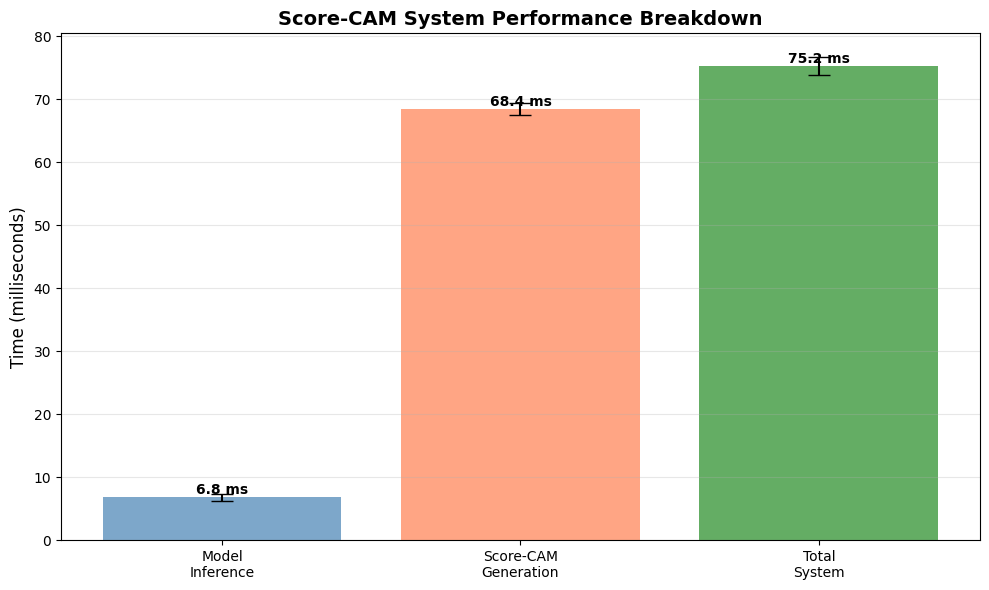

Efficiency plot saved as scorecam_efficiency_summary.png


In [26]:
# Simple visualization for thesis
def plot_efficiency_summary(results):
    """Create simple bar chart showing component breakdown"""
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    components = ['Model\nInference', 'Score-CAM\nGeneration', 'Total\nSystem']
    times = [
        results['model_inference']['mean_ms'],
        results['scorecam']['mean_ms'],
        results['total_system']['mean_ms']
    ]
    errors = [
        results['model_inference']['std_ms'],
        results['scorecam']['std_ms'],
        results['total_system']['std_ms']
    ]
    colors = ['steelblue', 'coral', 'forestgreen']
    
    bars = ax.bar(components, times, yerr=errors, capsize=8, alpha=0.7, color=colors)
    ax.set_ylabel('Time (milliseconds)', fontsize=12)
    ax.set_title('Score-CAM System Performance Breakdown', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, time in zip(bars, times):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{time:.1f} ms',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('scorecam_efficiency_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print('Efficiency plot saved as scorecam_efficiency_summary.png')

# Generate simple visualization
plot_efficiency_summary(results)